# Iris 데이터셋 분류

Setosa/Versicolor/Virginica 분류 - 다중 클래스 분류 문제

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 임포트 순서 이해하기
from sklearn import datasets # load_iris() 함수를 사용하기 위해서
from sklearn.model_selection import train_test_split # 훈련셋과 테스트셋 분리
from sklearn.preprocessing import StandardScaler # 표준화 특성 스케일링
from sklearn.neighbors import KNeighborsClassifier # KNN 모델
from sklearn.metrics import confusion_matrix, classification_report # 평가 지표 TP,..


# Iris 데이터셋 준비

In [2]:
iris = datasets.load_iris()# return_X_y: bool = False, as_frame: bool = False)

In [3]:
print(type(iris)) # {k:v}  #> Bunch 클래스 타입

<class 'sklearn.utils._bunch.Bunch'>


scikit - learn 패키지의 Bunch 클래스:
* Python의 dict와 비슷한 클래스
* key-value 쌍으로 아이템들을 저장하고 있음.
* dict_name['key'] 방식
* `bunch_name['key']` 또는 `bunch_name.key` 형식으로 key를 사용해서 value(값)을 참조할 수 있음.

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
x=iris['data'] # 특성 배열(feature array) .data도 가능
x[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [6]:
y=iris.target # 타겟 배열(target array)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [9]:
iris.target_names[:1]

array(['setosa'], dtype='<U10')

In [10]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [11]:
x,y = datasets.load_iris(return_X_y=True) # 변수 2개 선언
# 특성배열(x), 타겟배열(y)를 리턴.

In [12]:
# x는특성 y는타겟

In [13]:
iris_df=datasets.load_iris(as_frame=True)
# 데이터, 타겟을 DataFrame 타입으로 생성한 Bunch 객체를 리턴.
# False 훈련시킬때 , True 시각화할때

In [14]:
# iris_df.frame # target 있음
# iris_df.data # 컬럼4개
iris_df.target

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [15]:
print(type(iris_df))

<class 'sklearn.utils._bunch.Bunch'>


In [16]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [17]:
# iris1=sns.load_dataset('iris')

In [18]:
# x=iris1[['sepal_length','sepal_width']].values
# x

In [19]:
# y=iris1['species'].values
# y

In [20]:
# bae=[]
# count=np.arange(1,151)
# for xx in count:
#   knn=KNeighborsClassifier(n_neighbors=xx)
#   knn.fit(x,y)
#   bb=knn.score(x,y)
#   bae.append(bb)
# print(bae)




In [21]:
# plt.figure()

# plt.plot(X=x[:50,1],y=x[:50,0])
# plt.show()

# 훈련 셋, 테스트 셋 분리

train:test = 8:2, 층화 추출.

In [22]:

# x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=120,stratify=y)
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,stratify=y)

In [23]:
y_train.shape

(120,)

In [24]:
x_train.shape

(120, 4)

In [25]:
np.unique(y_train,return_counts=True)

(array([0, 1, 2]), array([40, 40, 40]))

In [26]:
np.unique(y_test,return_counts=True)

(array([0, 1, 2]), array([10, 10, 10]))

# 전처리 (표준화 특성 스케일링)

In [27]:
std_scaler=StandardScaler()

In [28]:
std_scaler.fit(X=x_train)

StandardScaler()

In [29]:
std_tr_scaler=std_scaler.transform(X=x_train)

In [30]:
std_te_scaler=std_scaler.transform(X=x_test)

# KNN 모델 생성, 훈련, 평가

In [31]:
knn=KNeighborsClassifier(n_neighbors=5)

In [32]:
knn.fit(X=std_tr_scaler,y=y_train)#표준화된 X와 일반y를 교육

KNeighborsClassifier()

In [33]:
knn.score(X=std_tr_scaler,y=y_train)

0.9666666666666667

In [34]:
knn.score(X=std_te_scaler,y=y_test)

0.9333333333333333

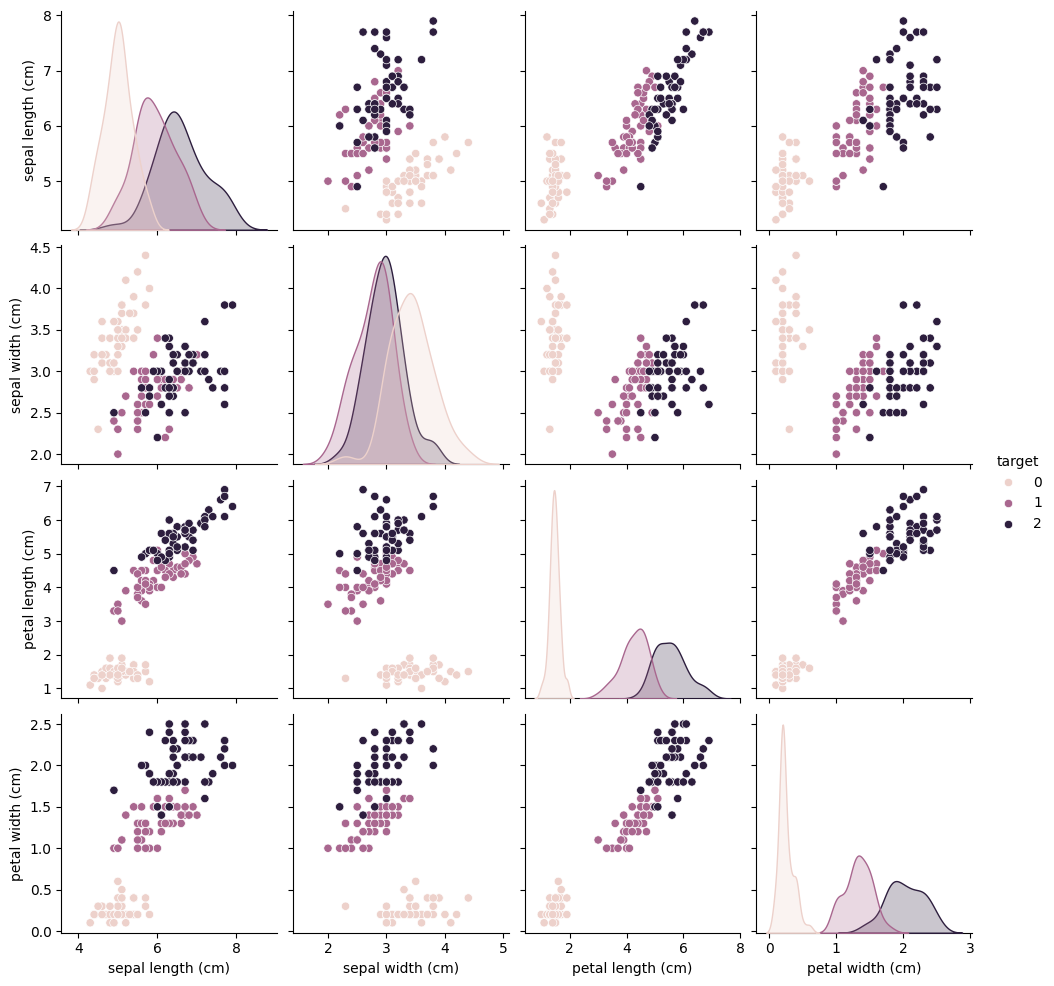

In [35]:
sns.pairplot(data=iris_df.frame,hue='target')
plt.show()

# k값의 따른 정확도의 변화

In [36]:
test_predict=knn.predict(std_tr_scaler)
test_predict

array([1, 0, 0, 2, 1, 0, 2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 2, 1, 1, 1, 0, 2,
       2, 1, 1, 1, 1, 0, 1, 2, 0, 1, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 1, 1,
       2, 1, 0, 1, 2, 2, 0, 0, 1, 2, 2, 2, 1, 1, 0, 2, 0, 2, 0, 1, 2, 1,
       2, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       2, 2, 0, 0, 1, 2, 0, 2, 2, 0, 2, 1, 0, 1, 2, 0, 0, 0, 2, 2, 1, 1,
       0, 1, 2, 2, 1, 0, 1, 0, 0, 2])

In [37]:
conf_mat=confusion_matrix(y_true=y_train,y_pred=test_predict)
conf_mat

array([[40,  0,  0],
       [ 0, 38,  2],
       [ 0,  2, 38]])

In [38]:
report=classification_report(y_true=y_train,y_pred=test_predict)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.95      0.95      0.95        40
           2       0.95      0.95      0.95        40

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



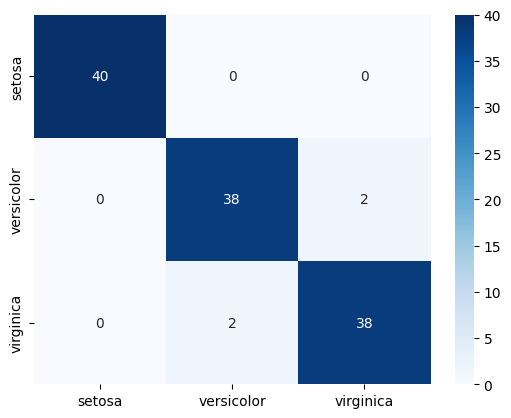

In [39]:
sns.heatmap(data=conf_mat, cmap='Blues',annot=True,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)# annot주석 ex)setosa ,...
plt.show()
#

In [40]:
# from sklearn.metrics import accuracy_score

In [41]:
# accuracy_score(y_true=y_train,y_pred=test_predict)

# 데이터 탐색

In [42]:
x[:6]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4]])

In [43]:
y[:6]

array([0, 0, 0, 0, 0, 0])

In [44]:
# 타겟의 비율
pd.Series(y).value_counts()

,count
0,50
1,50
2,50


In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,stratify=y,random_state=42)

In [46]:
x_train.shape

(120, 4)

In [47]:
x_test.shape

(30, 4)

In [48]:
y_train.shape

(120,)

In [49]:
pd.Series(y_train).value_counts()

,count
0,40
2,40
1,40


In [50]:
y_test.shape

(30,)

In [51]:
pd.Series(y_test).value_counts()

,count
0,10
2,10
1,10


In [52]:
std_scaler=StandardScaler() #스탠다드스케일러 객체생성

In [53]:
x_tr_scaled=std_scaler.fit_transform(X=x_train)
# fit_transform(): fit() 메서드 호출 후 평균과 표준편차를 사용해서 transform()까지 호출.
# (주의) fit_transform() 메서드는 훈련 셋만 아규먼트로 전달. 테스트 셋에서는 사용하면 안됨!

In [54]:
x_tr_scaled[:6]

array([[-1.72156775, -0.33210111, -1.34572231, -1.32327558],
       [-1.12449223, -1.22765467,  0.41450518,  0.6517626 ],
       [ 1.14439475, -0.5559895 ,  0.58484978,  0.25675496],
       [-1.12449223,  0.11567567, -1.28894078, -1.45494479],
       [-0.40800161, -1.22765467,  0.13059752,  0.12508575],
       [ 0.54731923, -1.22765467,  0.69841284,  0.91510102]])

In [55]:
x_te_scaled= std_scaler.transform(X=x_test)
x_te_scaled[:6]
# 테스트 셋을 스케일링할 때는 fit 또는 fit_transform은 사용하면 안됨 transform만 사용

array([[-1.72156775, -0.10821272, -1.40250384, -1.32327558],
       [ 0.30848902, -0.10821272,  0.64163131,  0.78343181],
       [-1.12449223, -1.45154306, -0.2668732 , -0.26992188],
       [-1.00507713, -1.67543145, -0.2668732 , -0.26992188],
       [-1.72156775,  0.33956406, -1.40250384, -1.32327558],
       [ 0.54731923,  0.56345245,  0.52806825,  0.52009339]])

In [56]:
knn=KNeighborsClassifier() # KNN 모델 생성

In [57]:
knn.fit(X=x_tr_scaled,y=y_train) # KNN 훈련

KNeighborsClassifier()

In [58]:
train_pred=knn.predict(X=x_tr_scaled)
train_pred[:10]

array([0, 1, 1, 0, 1, 2, 1, 2, 2, 2])

In [59]:
y_train[:10]

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2])

In [60]:
knn.score(X=x_tr_scaled,y=y_train)

0.975

In [61]:
conf_mat=confusion_matrix(y_true=y_train,y_pred=train_pred)

In [62]:
conf_mat

array([[40,  0,  0],
       [ 0, 39,  1],
       [ 0,  2, 38]])

레이블이 1인 샘플을 레이블이 2로 잘못 예측한 것이 1개 ,
레이블이 2인 샘플을 레이블 1로 잘못 예측한 것이 2개.

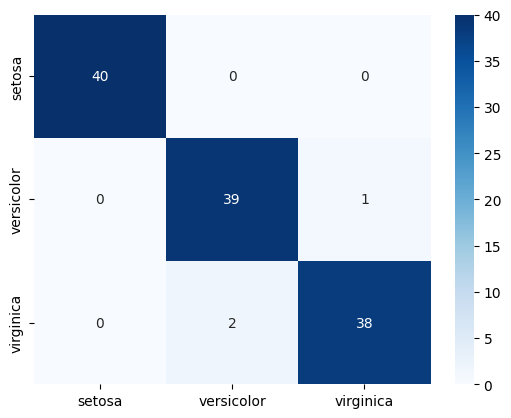

In [63]:
# 혼동 행렬(confusion matrix)시각화
sns.heatmap(data=conf_mat, cmap='Blues', annot=True,
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.show()

In [64]:
print(classification_report(y_true=y_train,y_pred=train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.95      0.97      0.96        40
           2       0.97      0.95      0.96        40

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



In [65]:
test_pred = knn.predict(X=x_te_scaled)
test_pred # 테스트 셋의 예측값

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       1, 1, 2, 1, 1, 0, 2, 0])

In [66]:
y_test # 테스트 셋의 실젯값

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [67]:
knn.score(X=x_te_scaled,y=y_test)

0.9333333333333333

In [68]:
conf_mat_test=confusion_matrix(y_true=y_test,y_pred=test_pred)

In [69]:
conf_mat_test

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  2,  8]])

실제 레이블이 2(virginica)인 샘플을 레이블이 1(versicolor)로 잘못 예측한 것이 2개.

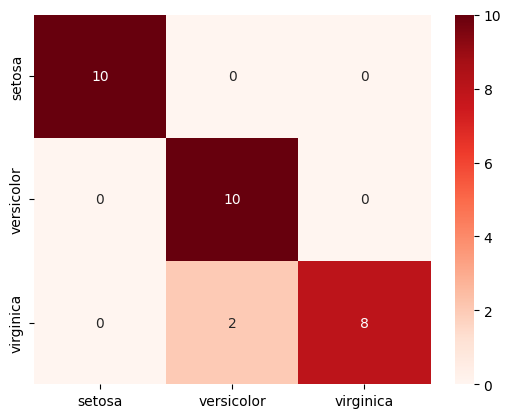

In [70]:
sns.heatmap(data=conf_mat_test,cmap='Reds',annot=True,
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.show()

In [71]:
10/12

0.8333333333333334

In [72]:
print(classification_report(y_true=y_test,y_pred=test_pred)) #
# 각각의 정밀도 재현률 계산값
# EX) versicolor 10 0  TP FN     pre  10/12 TP/TP+FP
#                 2 8  FP TN     rec  10/10 TP/TP+FN

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [ ]:
# 어떤 k가 진짜k인가를 알기위해서

In [73]:
k_values=np.arange(1,100)
train_accs=[] # 훈련 셋에서의 정확도를 저장할 리스트
test_accs=[] # 테스트 셋에서의 정확도를 저장할 리스트

for k in k_values: # k 값을 1~99까지 변화
  knn=KNeighborsClassifier(n_neighbors=k) # KNN 모델 생성
  knn.fit(X=x_tr_scaled,y=y_train) # KNN 모델 훈련
  tr_acc=knn.score(X=x_tr_scaled,y=y_train) # 훈련 셋 정확도
  train_accs.append(tr_acc)
  te_acc=knn.score(X=x_te_scaled,y=y_test)
  test_accs.append(te_acc)
print(train_accs)
print(test_accs)

[1.0, 0.9666666666666667, 0.9583333333333334, 0.9583333333333334, 0.975, 0.9583333333333334, 0.975, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9583333333333334, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9583333333333334, 0.9666666666666667, 0.9416666666666667, 0.9583333333333334, 0.95, 0.9583333333333334, 0.9583333333333334, 0.95, 0.9583333333333334, 0.9333333333333333, 0.9333333333333333, 0.925, 0.9166666666666666, 0.9166666666666666, 0.9, 0.8916666666666667, 0.8916666666666667, 0.8833333333333333, 0.875, 0.8833333333333333, 0.8833333333333333, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.8916666666666667, 0.875, 0.8916666666666667, 0.8833333333333333, 0.8833333333333333, 0.8833333333333333, 0.8833333333333333, 0.8833333333333333, 0.8833333333333333, 0.8833333333333333, 0.875, 0.875, 0.875, 0

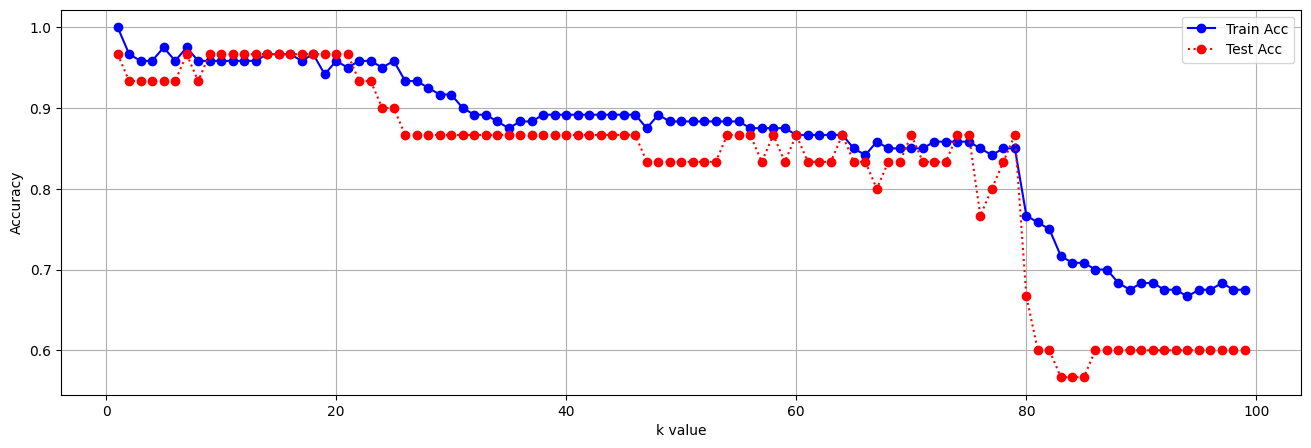

In [74]:
# 훈련 셋의 정확도 시각화
plt.figure(figsize=(16,5))
plt.plot(k_values,train_accs, 'bo-',label='Train Acc')

# 테스트 셋의 정확도 시각화
plt.plot(k_values,test_accs, 'ro:',label='Test Acc')
plt.legend()
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

* 과(대)적합: over-fitting. 훈련 셋에서의 정확도가 테스트 셋에서의 정확도보다 큰 경우.
* 과(소)적합: under-fitting. 훈련 셋에서의 정확도가 테스트 셋에서의 정확도보다 작은 경우.
* 지도학습에서는 일반적으로 과대적합이 일어나기가 쉬움.
    * 좋은 머신 러닝 모델은 과대적합의 크기가 작은 경우. 훈련 셋의 정확도와 테스트 셋의 정확도 차이가 작은 경우.
* 과소적합은 샘플의 개수가 적은 경우에 잘 나타남.
    * 과소적합을 줄이기 위해서는 샘플들을 더 많이 수집해야한다.    

# Breast Cancer 데이터셋

In [75]:
cancer= datasets.load_breast_cancer()

In [76]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [77]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [78]:
x=cancer.data # 특성 배열
y=cancer.target # 타겟 배열

In [79]:
x.shape # 569,30 =sample, features


(569, 30)

In [80]:
y.shape # 569, = sample

(569,)

In [81]:
x[:5]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
        1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
        4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
        2.250e-02, 4.571e-03, 2.357e

In [82]:
y[:5]

array([0, 0, 0, 0, 0])

In [83]:
pd.Series(y).value_counts().sort_index()

,count
0,212
1,357


breast cancer 데이터의 클래스
* 0 - Malignant, 양성. 암.
* 1 - Benign, 음성. 암이 아님.

In [84]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,stratify=y,random_state=42)

In [85]:
x_train.shape

(398, 30)

In [86]:
y_train.shape

(398,)

In [87]:
x_test.shape

(171, 30)

In [88]:
y_test.shape

(171,)

In [89]:
pd.Series(y_train).value_counts()

,count
1,250
0,148


In [90]:
pd.Series(y_test).value_counts()

,count
1,107
0,64


In [91]:
398+171

569

In [92]:
std_scaler=StandardScaler() #표준화는 트랜스폼이필요하다

In [93]:
stdtr_scaler=std_scaler.fit_transform(X=x_train)
stdtr_scaler[:5]

array([[-7.09820775e-01, -2.58416998e-01, -6.37396194e-01,
        -7.11995812e-01,  1.62843044e+00,  8.47288664e-01,
         1.66500733e-01,  1.96419541e-01,  5.42716416e-01,
         1.34715060e+00,  7.88844881e-02,  1.00097591e+00,
         1.48626761e-01, -3.02470418e-01,  2.51058541e+00,
         3.58612416e-01,  5.21559057e-01,  1.08389476e+00,
        -2.98854985e-01,  4.85353093e-01, -6.00068234e-01,
        -6.58674678e-02, -5.65661585e-01, -6.22613493e-01,
         2.01922243e+00,  1.86202349e-01,  1.80187463e-01,
         4.00932811e-01, -4.14074391e-01,  4.45223331e-01],
       [-8.30331364e-01,  2.23112660e+00, -8.74979940e-01,
        -7.79080797e-01, -1.59756876e+00, -1.26771706e+00,
        -1.08647139e+00, -1.24323171e+00, -2.65854287e+00,
        -1.05269949e+00, -3.37600495e-01,  4.98258297e+00,
        -4.29665100e-01, -4.49542464e-01,  2.02106560e-01,
        -8.82510485e-01, -9.63340966e-01, -1.81717670e+00,
        -9.05875403e-02, -6.99436375e-01, -8.97360624e-

In [94]:
stdte_scaler=std_scaler.transform(X=x_test)
stdte_scaler

array([[-0.10439853,  0.72716639,  0.0790998 , ...,  1.5719972 ,
         1.02470396,  3.09424252],
       [-0.31385741,  0.32002924, -0.34072857, ..., -0.76185132,
         0.40984142, -1.04484997],
       [-0.63234968, -0.44085004, -0.6448857 , ..., -0.37001791,
        -1.09042319, -1.25614078],
       ...,
       [ 0.69039749, -0.23394427,  0.6200085 , ..., -0.34384639,
        -0.82295798, -1.0269796 ],
       [-0.19047753,  0.06417802, -0.24378109, ...,  0.02240695,
        -0.06975137, -0.55288926],
       [-0.34541971, -0.81016571, -0.31701181, ..., -0.18903523,
        -1.43013475, -0.68113543]])

In [95]:
knn=KNeighborsClassifier()

In [96]:
knn.fit(X=stdtr_scaler,y=y_train)

KNeighborsClassifier()

In [97]:
knn.score(X=stdtr_scaler,y=y_train)

0.9723618090452262

In [98]:
knn.score(X=stdte_scaler,y=y_test)

0.9590643274853801

In [99]:
testpred=knn.predict(X=stdte_scaler)
print(testpred)

[0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0
 1 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 0 1
 1 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1]


In [100]:
print(y_test[:10])
print(testpred[:10])

[0 1 1 0 0 0 1 0 1 0]
[0 1 1 0 1 0 1 0 1 0]


In [101]:
cm=confusion_matrix(y_true=y_test,y_pred=testpred)
cm

array([[ 57,   7],
       [  0, 107]])

In [102]:
report=classification_report(y_true=y_test,y_pred=testpred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



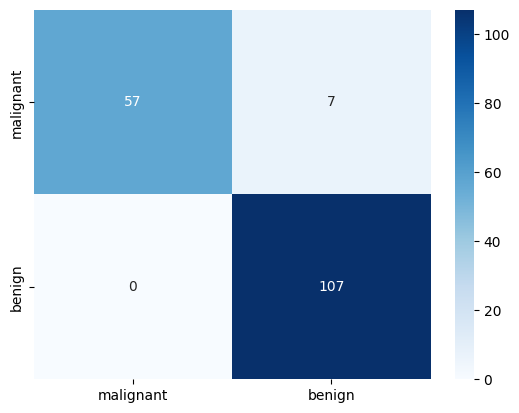

In [103]:

sns.heatmap(cm, annot=True, fmt='d',cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.show()

In [104]:
stdtr_scaler.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [105]:
print(cancer.target_names)
print(np.unique(y, return_counts=True))
print(np.unique(y_test, return_counts=True))

['malignant' 'benign']
(array([0, 1]), array([212, 357]))
(array([0, 1]), array([ 64, 107]))


In [106]:
print(confusion_matrix(y_test, testpred))
print(testpred[:20])

[[ 57   7]
 [  0 107]]
[0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 0 1 1 1]


In [107]:
# plt.figure(figsize=(10, 4))

# plt.subplot(1, 2, 1)
# sns.boxplot(y=X[feature])
# plt.title("Before Scaling")

# plt.subplot(1, 2, 2)
# sns.boxplot(y=X_scaled[feature])
# plt.title("After Scaling")

# plt.show()

In [108]:
x=cancer.data # 특성 배열
y=cancer.target # 타겟 배열

## 훈련 셋, 테스트 셋 분리

In [109]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,stratify=y,random_state=42)

In [110]:
x_train.shape

(398, 30)

In [111]:
x_test.shape

(171, 30)

In [112]:
pd.Series(y_train).value_counts(normalize=True) # 노멀라이즈 비율

,proportion
1,0.628141
0,0.371859


In [113]:
pd.Series(y_test).value_counts(normalize=True) # 노멀라이즈 비율

,proportion
1,0.625731
0,0.374269


## 특성 스케일링

In [114]:
std_scaler=StandardScaler()

In [115]:
x_tr_scaled=std_scaler.fit_transform(X=x_train)
x_tr_scaled[:3]

array([[-0.70982078, -0.258417  , -0.63739619, -0.71199581,  1.62843044,
         0.84728866,  0.16650073,  0.19641954,  0.54271642,  1.3471506 ,
         0.07888449,  1.00097591,  0.14862676, -0.30247042,  2.51058541,
         0.35861242,  0.52155906,  1.08389476, -0.29885498,  0.48535309,
        -0.60006823, -0.06586747, -0.56566159, -0.62261349,  2.01922243,
         0.18620235,  0.18018746,  0.40093281, -0.41407439,  0.44522333],
       [-0.83033136,  2.2311266 , -0.87497994, -0.7790808 , -1.59756876,
        -1.26771706, -1.08647139, -1.24323171, -2.65854287, -1.05269949,
        -0.33760049,  4.98258297, -0.4296651 , -0.44954246,  0.20210656,
        -0.88251048, -0.96334097, -1.8171767 , -0.09058754, -0.69943637,
        -0.89736062,  1.97515343, -0.94957443, -0.7793308 , -1.74765214,
        -1.22937204, -1.25894675, -1.69278836, -2.09572345, -1.32341746],
       [-1.01109725, -0.22726989, -1.03517213, -0.91177961, -1.07777861,
        -1.0980963 , -0.84165046, -0.9557672 ,  2

In [116]:
x_te_scaled=std_scaler.transform(X=x_test)
x_te_scaled[:3]

array([[-1.04398533e-01,  7.27166392e-01,  7.90997957e-02,
        -2.13271909e-01,  1.29840495e+00,  2.36712067e+00,
         1.52757241e+00,  8.33188362e-01,  9.42427720e-01,
         1.93171191e+00, -7.80115789e-01, -5.35220664e-02,
        -4.17935042e-01, -5.54593925e-01, -1.82309943e-01,
         1.82020569e+00,  6.83188973e-01,  7.48246622e-01,
        -1.22628686e-01,  1.47474174e+00, -2.55291644e-01,
         9.79957971e-01,  4.68202202e-02, -3.22282920e-01,
         1.44975470e+00,  3.13273204e+00,  1.87724561e+00,
         1.57199720e+00,  1.02470396e+00,  3.09424252e+00],
       [-3.13857413e-01,  3.20029236e-01, -3.40728575e-01,
        -3.86574787e-01,  1.32840726e+00, -5.11366096e-01,
        -7.01243883e-01, -5.58854001e-01,  2.62335651e+00,
        -2.51836800e-01,  1.22702179e-01,  2.29031681e-01,
         5.83053145e-02, -1.00246354e-01,  1.17131502e-02,
        -7.46416342e-01, -3.79976695e-01, -2.64483162e-04,
         1.01025467e+00, -7.82000101e-01, -4.34905796e-

## KNN 모델 생성, 훈련, 평가

In [117]:
knn=KNeighborsClassifier() # KNN 모델 생성

In [118]:
knn.fit(X=x_tr_scaled,y=y_train) # KNN 모델 훈련

KNeighborsClassifier()

In [119]:
train_pred=knn.predict(X=x_tr_scaled) # 훈련 셋에서의 예측값
train_pred[:5]

array([1, 1, 1, 1, 1])

In [120]:
y_train[:5]

array([1, 1, 1, 1, 1])

In [121]:
knn.score(X=x_tr_scaled,y=y_train) # 훈련 셋에서의 정확도

0.9723618090452262

In [122]:
conf_mat=confusion_matrix(y_true=y_train,y_pred=train_pred)
conf_mat

array([[139,   9],
       [  2, 248]])

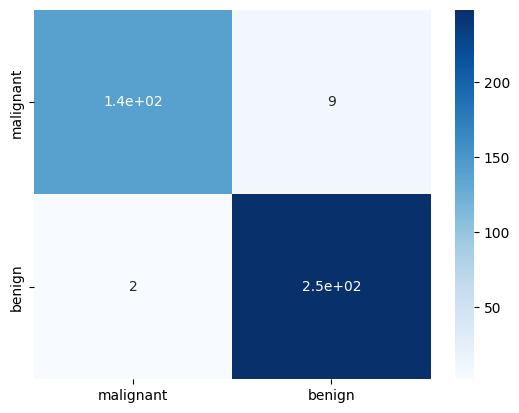

In [123]:
sns.heatmap(data=conf_mat, cmap='Blues',annot=True,
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.show()
#

In [124]:
test_pred=knn.predict(X=x_te_scaled) # 테스트 셋에서의 예측값
test_pred[:5]


array([0, 1, 1, 0, 1])

In [125]:
y_test[:5]

array([0, 1, 1, 0, 0])

In [126]:
conf_mat_test=confusion_matrix(y_true=y_test,y_pred=test_pred)
print(conf_mat_test)

[[ 57   7]
 [  0 107]]


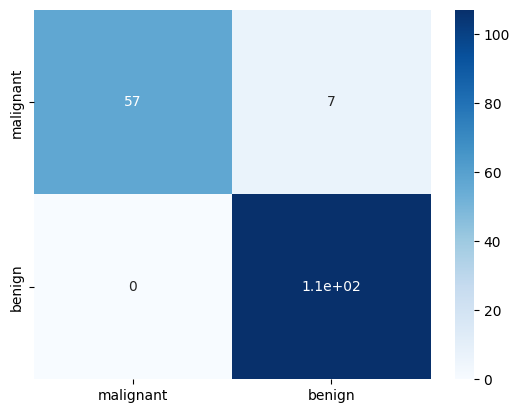

In [127]:
# 나는 테스트만 했다 트레인으로도 만들면 같다
sns.heatmap(data=conf_mat_test,cmap='Blues',annot=True,
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.show()

## 하이퍼 파라미터 튜닝( 최적의 k값 찾기)

In [128]:
k_values=np.arange(1,100)# 뒤로갈수록 성능안좋아지니까 대략 100개잡음
train_accs=[]
test_accs=[]

for k in k_values:  # k=1~99반복
  knn=KNeighborsClassifier(n_neighbors=k) # KNN모델 반복
  knn.fit(X=x_tr_scaled,y=y_train) # KNN 모델 훈련
  train_accs.append(knn.score(X=x_tr_scaled,y=y_train))
  test_accs.append(knn.score(X=x_te_scaled,y=y_test))

print(train_accs)
print(test_accs)

[1.0, 0.9773869346733668, 0.9723618090452262, 0.9824120603015075, 0.9723618090452262, 0.9723618090452262, 0.9723618090452262, 0.9698492462311558, 0.9698492462311558, 0.9698492462311558, 0.9723618090452262, 0.9673366834170855, 0.9698492462311558, 0.9698492462311558, 0.9698492462311558, 0.9698492462311558, 0.9673366834170855, 0.9698492462311558, 0.964824120603015, 0.9623115577889447, 0.9623115577889447, 0.9623115577889447, 0.9673366834170855, 0.9673366834170855, 0.9673366834170855, 0.964824120603015, 0.964824120603015, 0.964824120603015, 0.9597989949748744, 0.9623115577889447, 0.9597989949748744, 0.9597989949748744, 0.957286432160804, 0.9547738693467337, 0.957286432160804, 0.9547738693467337, 0.9547738693467337, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.9522613065326633, 0.949748743718593, 0.949748743718593, 0.

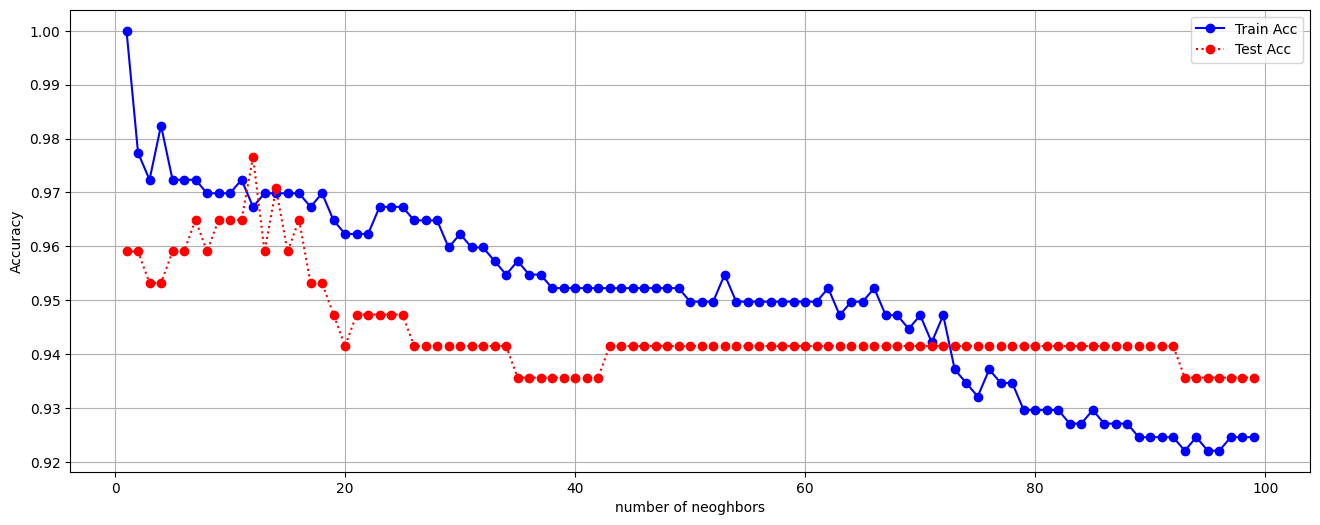

In [129]:
plt.figure(figsize=(16,6))

# 훈련 셋 정확도 시각화
plt.plot(k_values,train_accs, 'bo-',label='Train Acc')
# 테스트 셋 정확도 시각화
plt.plot(k_values,test_accs, 'ro:',label='Test Acc')
plt.legend()
plt.grid()
plt.xlabel('number of neoghbors')
plt.ylabel('Accuracy')
plt.show()
# k=7로 놓고 재현율과 정확

# k=7일때 일반화 성능

In [130]:
knn=KNeighborsClassifier(n_neighbors=7)


In [131]:
knn.fit(X=x_tr_scaled,y=y_train)

KNeighborsClassifier(n_neighbors=7)

In [132]:
train_pred=knn.predict(X=x_tr_scaled)
train_pred
print(classification_report(y_true=y_train,y_pred=train_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       148
           1       0.97      0.99      0.98       250

    accuracy                           0.97       398
   macro avg       0.97      0.97      0.97       398
weighted avg       0.97      0.97      0.97       398



In [133]:
test_pred=knn.predict(X=x_te_scaled)
print(classification_report(y_true=y_test,y_pred=test_pred,target_names=cancer.target_names))#target_names=cancer.target_names 0,1이 아닌 원래 찾던값나오도록

              precision    recall  f1-score   support

   malignant       1.00      0.91      0.95        64
      benign       0.95      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171

